In [1]:
# =============================================================================
# Adult Income Prediction — Data Preprocessing Pipeline
# Covers: 3.1 Missing Values + Encoding/Scaling
#         3.2 Class Imbalance Strategy
#         3.3 Feature Engineering
# =============================================================================
#
# Requirements:
#   pip install pandas numpy matplotlib seaborn scikit-learn category_encoders
#
# =============================================================================

# ── STEP 0: Imports ──────────────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# category_encoders gives us TargetEncoder for native-country
import category_encoders as ce

# ── Global plot style ────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.labelsize": 10})

In [2]:
# =============================================================================
# STEP 1 — Load the raw CSV
# =============================================================================
# The CSV uses the standard UCI column names.
# Strip whitespace from string columns right away (UCI files often have
# leading spaces after commas).

df = pd.read_csv("../data/raw/census_income_full.csv")

# Strip leading/trailing whitespace from every string column
str_cols = df.select_dtypes(include="object").columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

print("── Raw dataset ──")
print(f"Shape : {df.shape}")
print(df.head(3))

── Raw dataset ──
Shape : (48842, 15)
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   

       marital-status         occupation   relationship   race   sex  \
0       Never-married       Adm-clerical  Not-in-family  White  Male   
1  Married-civ-spouse    Exec-managerial        Husband  White  Male   
2            Divorced  Handlers-cleaners  Not-in-family  White  Male   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             0              13  United-States  <=50K  
2             0             0              40  United-States  <=50K  


In [3]:
# STEP 2 — Inspect missing values (represented as '?' in the UCI file)
# =============================================================================
# Replace '?' with NaN so pandas treats them as missing
df.replace("?", np.nan, inplace=True)

# ── Normalize income labels ──────────────────────────────────────────────────
# The UCI dataset has two label variants:
#   - Training portion: '<=50K' and '>50K'   (no trailing dot)
#   - Test portion:     '<=50K.' and '>50K.'  (with trailing dot)
# We unify them to '<=50K' and '>50K' so all downstream code sees 2 classes.
df["income"] = df["income"].str.rstrip(".")

print("\n── Missing values after replacing '?' ──")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n── Income label check (should be exactly 2 classes) ──")
print(df["income"].value_counts())



── Missing values after replacing '?' ──
workclass         2799
occupation        2809
native-country     857
dtype: int64

── Income label check (should be exactly 2 classes) ──
income
<=50K    37155
>50K     11687
Name: count, dtype: int64


---
### STEP 2b — Remove Duplicate Rows
Duplicate rows can bias the model and distort evaluation metrics. We check for and remove any exact duplicates.


In [4]:
# =============================================================================
# STEP 2b — Remove Duplicate Rows
# =============================================================================
print(f"Shape before removing duplicates: {df.shape}")
n_dups = df.duplicated().sum()
print(f"Number of duplicate rows found: {n_dups}")

df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates:  {df.shape}")


Shape before removing duplicates: (48842, 15)
Number of duplicate rows found: 52
Shape after removing duplicates:  (48790, 15)


---
### STEP 2c — Drop `fnlwgt` Column
The `fnlwgt` column represents Census Bureau sampling weights — it is a survey design artifact, **not a meaningful demographic or socioeconomic feature**. Including it in modeling could introduce misleading correlations, so we drop it.


In [5]:
# =============================================================================
# STEP 2c — Drop fnlwgt (Census Bureau sampling weight)
# =============================================================================
# fnlwgt is a survey design artifact, not a demographic/socioeconomic
# attribute.  It should not be used as a predictor for income.

df.drop(columns=["fnlwgt"], inplace=True)
print(f"\nShape after dropping fnlwgt: {df.shape}")
print(df.head(3))


Shape after dropping fnlwgt: (48790, 14)
   age         workclass  education  education-num      marital-status  \
0   39         State-gov  Bachelors             13       Never-married   
1   50  Self-emp-not-inc  Bachelors             13  Married-civ-spouse   
2   38           Private    HS-grad              9            Divorced   

          occupation   relationship   race   sex  capital-gain  capital-loss  \
0       Adm-clerical  Not-in-family  White  Male          2174             0   
1    Exec-managerial        Husband  White  Male             0             0   
2  Handlers-cleaners  Not-in-family  White  Male             0             0   

   hours-per-week native-country income  
0              40  United-States  <=50K  
1              13  United-States  <=50K  
2              40  United-States  <=50K  


---
## EDA — Part A: Dataset Overview & Class Distribution
Before any preprocessing, we visualise the raw dataset to understand distributions, class imbalance, and feature relationships as described in Section 2 of the project outline.

---
### EDA 1 — Target Class Distribution

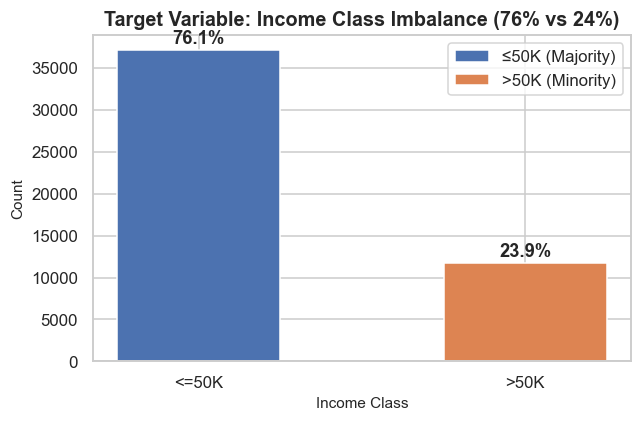


Imbalance ratio (majority/minority): 76.1% / 23.9%


In [6]:
# =============================================================================
# EDA 1 — Target Class Distribution
# =============================================================================
# Section 2: 76.1% ≤50K vs 23.9% >50K — visualise the imbalance.
# Blue (#4C72B0) represents the ≤50K class, Orange (#DD8452) represents >50K.

income_counts = df["income"].value_counts()
income_pct    = df["income"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))

colors = {
    "<=50K": "#4C72B0",  # Blue  = income ≤50K (majority class)
    ">50K":  "#DD8452",  # Orange = income >50K (minority class)
}

bar_colors = [colors.get(label, "#999999") for label in income_counts.index]

bars = ax.bar(income_counts.index, income_counts.values,
              color=bar_colors, edgecolor="white", width=0.5)
for bar, pct in zip(bars, income_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 300, f"{pct:.1f}%",
            ha="center", va="bottom", fontweight="bold")
ax.set_title("Target Variable: Income Class Imbalance (76% vs 24%)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Income Class")
ax.set_ylabel("Count")

# Add legend to clarify the colors
import matplotlib.patches as mpatches
legend_elements = [mpatches.Patch(facecolor="#4C72B0", label="≤50K (Majority)"),
                   mpatches.Patch(facecolor="#DD8452", label=">50K (Minority)")]
ax.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.show()
print(f"\nImbalance ratio (majority/minority): {income_pct.max():.1f}% / {income_pct.min():.1f}%")

---
### EDA 2 — Missing Value Summary

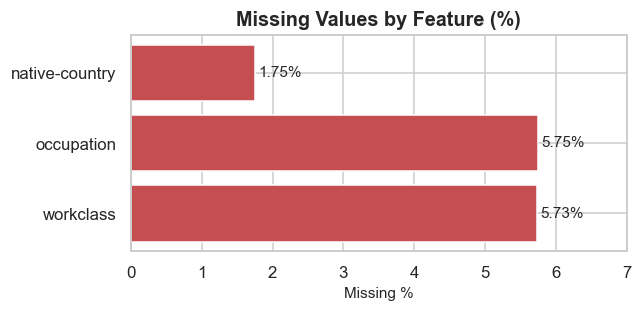

       Feature  Missing Count  Missing %
     workclass           2795       5.73
    occupation           2805       5.75
native-country            856       1.75


In [7]:
# =============================================================================
# EDA 2 — Missing Value Summary
# =============================================================================
# Visual audit of the three columns with '?' missing values.
# Only the bar chart is shown — the missingness heatmap was removed as it
# adds little insight beyond "some rows have missing values".

missing_df = df.isnull().sum().reset_index()
missing_df.columns = ["Feature", "Missing Count"]
missing_df = missing_df[missing_df["Missing Count"] > 0].copy()
missing_df["Missing %"] = (missing_df["Missing Count"] / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(6, 3))

bars = ax.barh(missing_df["Feature"], missing_df["Missing %"],
               color="#C44E52", edgecolor="white")
for bar, val in zip(bars, missing_df["Missing %"]):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}%", va="center", fontsize=10)
ax.set_xlim(0, 7)
ax.set_title("Missing Values by Feature (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Missing %")

plt.tight_layout()
plt.show()
print(missing_df.to_string(index=False))

---
### EDA 3 — Categorical Feature Distributions & Income Rate
For each categorical feature, we show:
- **Left panel**: the count distribution of each category.
- **Right panel**: the **>50K income rate** per category.

> **Important**: The ">50K Rate" is a **conditional probability** — it shows `P(>50K | category)`, i.e., the fraction of individuals within each category who earn >50K. These rates do **not** sum to 1 across categories. The dashed line shows the overall average >50K rate (~24%).


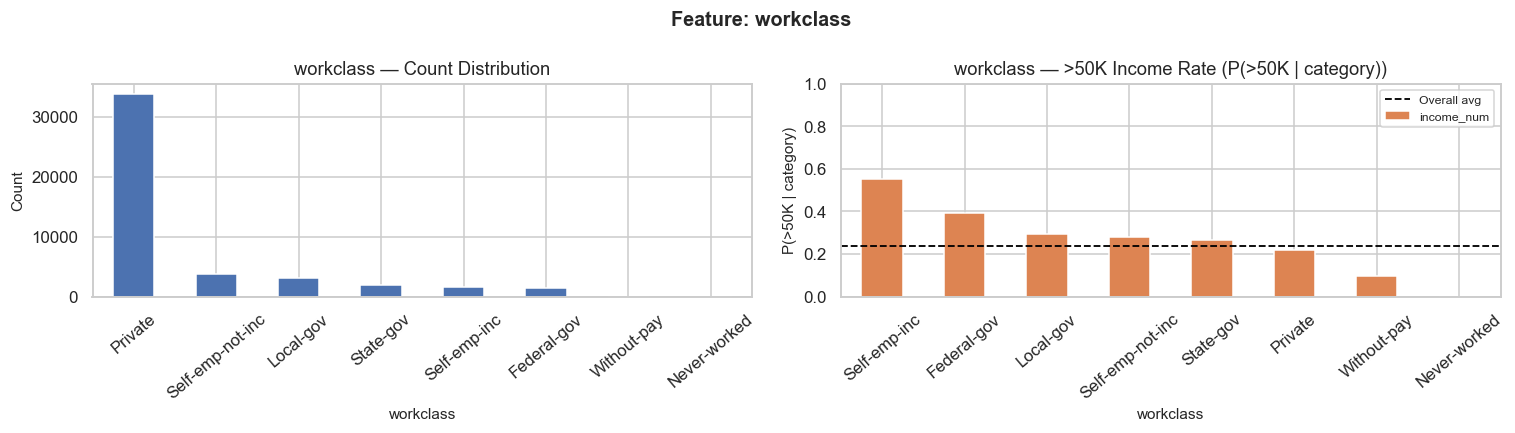

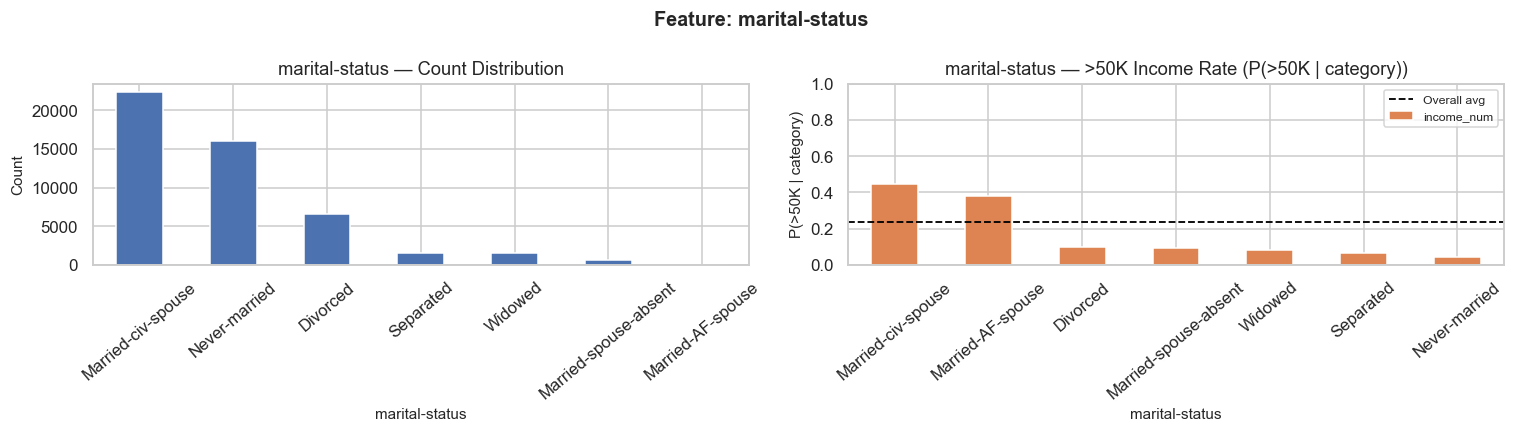

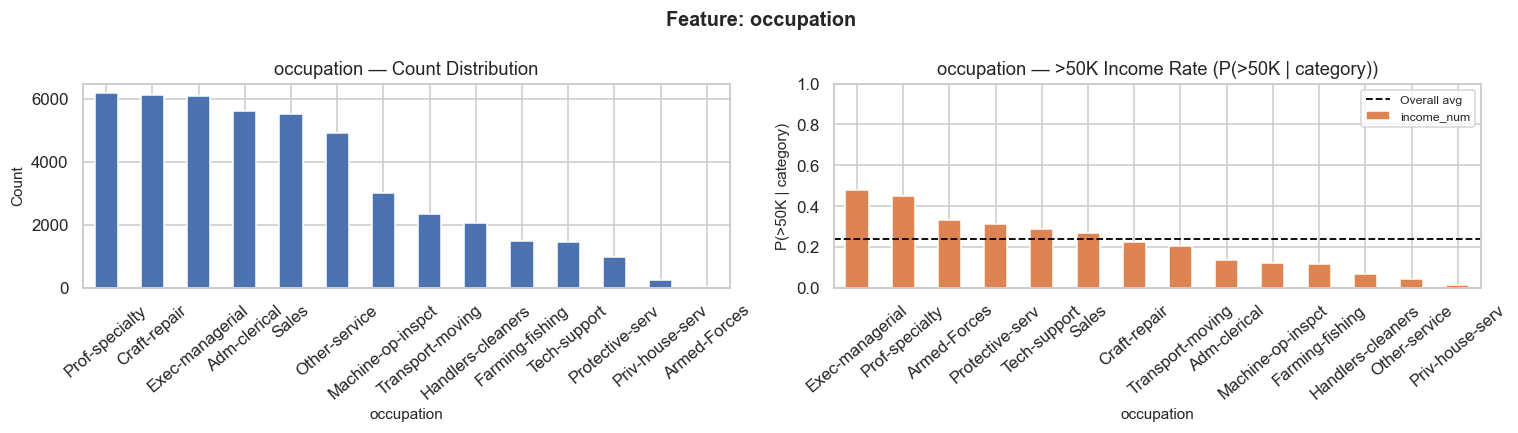

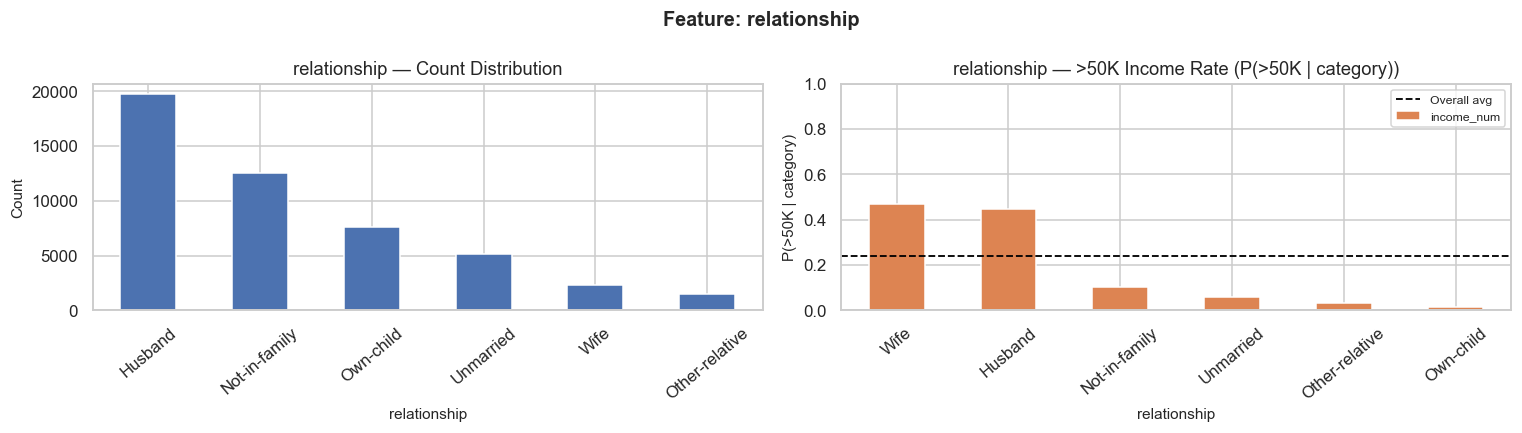

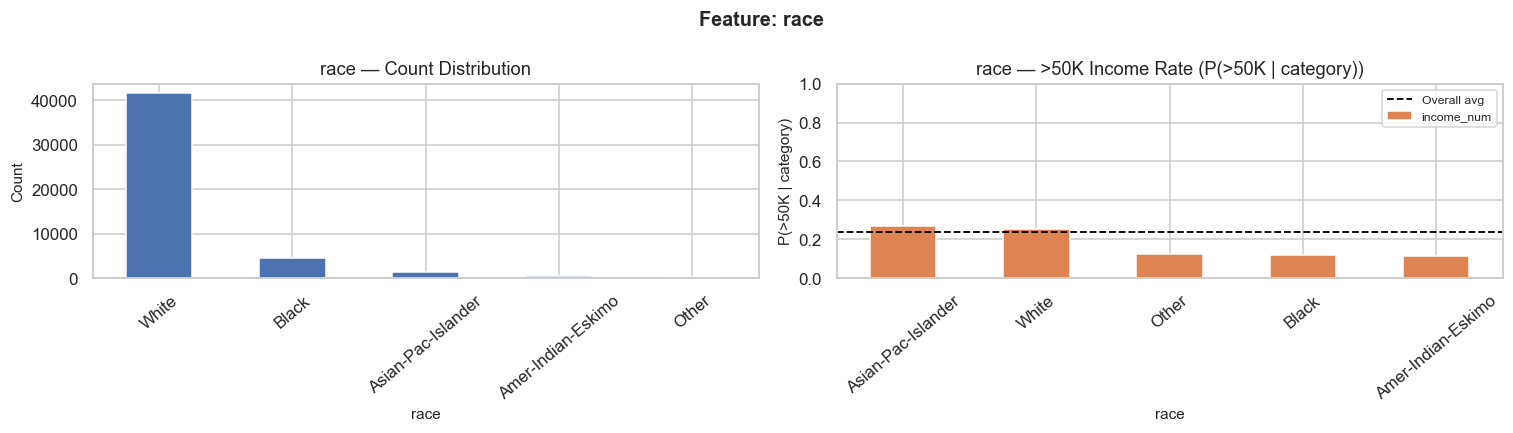

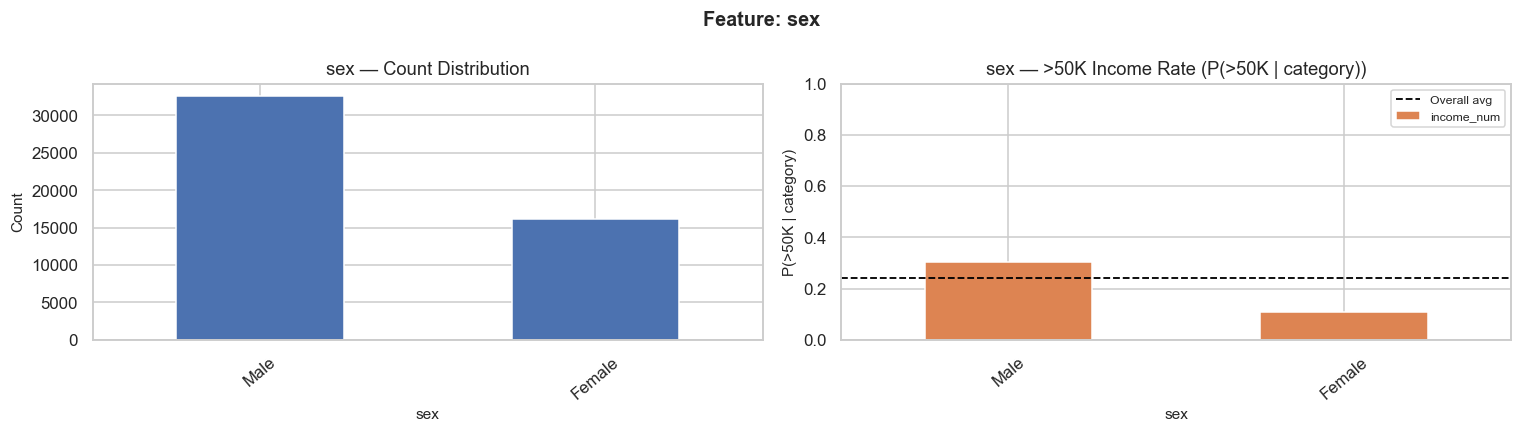

In [8]:
# =============================================================================
# EDA 3 — Categorical Feature Distributions & Income Rate
# =============================================================================
# For each categorical column: count distribution + >50K rate by category.
# The >50K Rate is P(income > 50K | category), NOT a distribution that sums to 1.
# The dashed line shows the overall average >50K rate.

# Create a temporary numeric target for rate calculation
df_eda = df.copy()
# Income labels were already normalized in STEP 2 (no trailing dots)
df_eda["income_num"] = (df_eda["income"] == ">50K").astype(int)

cat_features = ["workclass", "marital-status", "occupation",
                "relationship", "race", "sex"]

for col in cat_features:
    counts    = df_eda[col].value_counts()
    rate      = df_eda.groupby(col)["income_num"].mean().sort_values(ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Distribution
    counts.plot(kind="bar", color="#4C72B0", ax=axes[0], edgecolor="white")
    axes[0].set_title(f"{col} — Count Distribution")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=40)

    # >50K rate (conditional probability P(>50K | category))
    bars = rate.plot(kind="bar", color="#DD8452", ax=axes[1], edgecolor="white")
    axes[1].set_title(f"{col} — >50K Income Rate (P(>50K | category))")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("P(>50K | category)")
    axes[1].set_ylim(0, 1.0)
    axes[1].axhline(df_eda["income_num"].mean(), color="black",
                    linestyle="--", linewidth=1.2, label="Overall avg")
    axes[1].legend(fontsize=8)
    axes[1].tick_params(axis="x", rotation=40)

    plt.suptitle(f"Feature: {col}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


---
### EDA 4 — Numeric Feature Distributions (Histogram + Boxplot)
Box plots show the distribution of each numeric feature split by income class. This helps identify which features have noticeably different distributions between the two income groups, which is a strong indicator of predictive power.


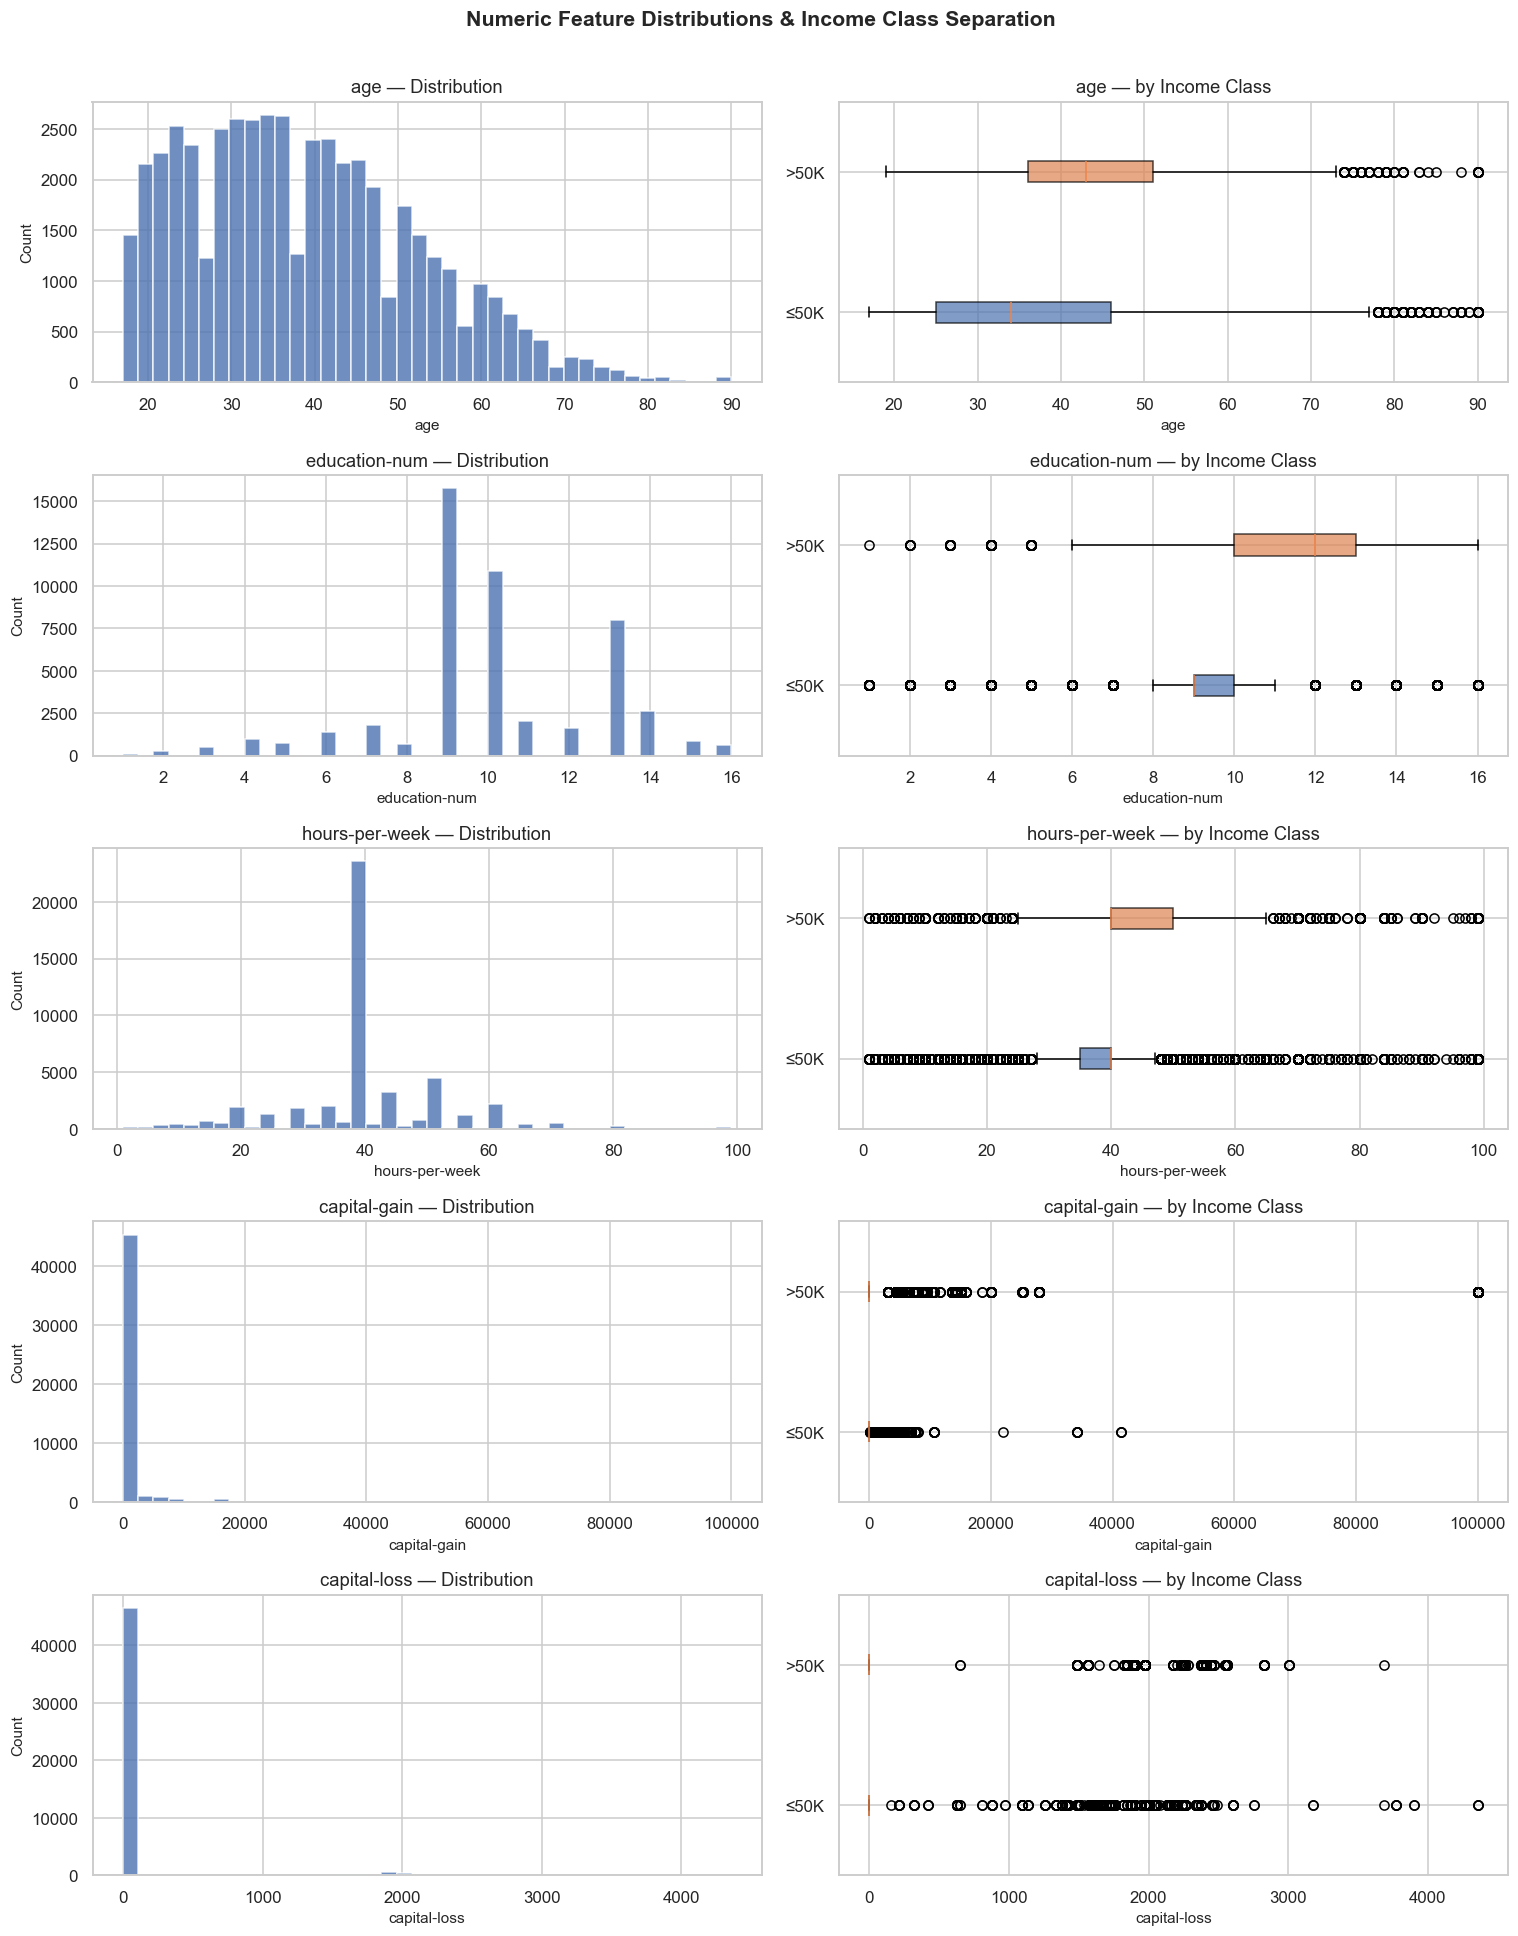

In [9]:
# =============================================================================
# EDA 4 — Numeric Feature Distributions (Histogram + Boxplot)
# =============================================================================
# Boxplots split by income class are useful for understanding which
# numeric features separate the two classes well.

num_cols = ["age", "education-num",
            "hours-per-week", "capital-gain", "capital-loss"]

fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 3.5 * len(num_cols)))

for i, col in enumerate(num_cols):
    # Histogram
    axes[i, 0].hist(df_eda[col].dropna(), bins=40,
                    color="#4C72B0", alpha=0.8, edgecolor="white")
    axes[i, 0].set_title(f"{col} — Distribution")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Count")

    # Boxplot split by income class
    groups = [df_eda[df_eda["income_num"] == 0][col].dropna(),
              df_eda[df_eda["income_num"] == 1][col].dropna()]
    bp = axes[i, 1].boxplot(groups, vert=False, patch_artist=True,
                             labels=["≤50K", ">50K"])
    for patch, color in zip(bp["boxes"], ["#4C72B0", "#DD8452"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i, 1].set_title(f"{col} — by Income Class")
    axes[i, 1].set_xlabel(col)

plt.suptitle("Numeric Feature Distributions & Income Class Separation",
             fontsize=14, fontweight="bold", y=1.005)
plt.tight_layout()
plt.show()


#### Overall Numeric Feature Distributions (Boxplot)

This visualization helps identify outliers across the dataset.

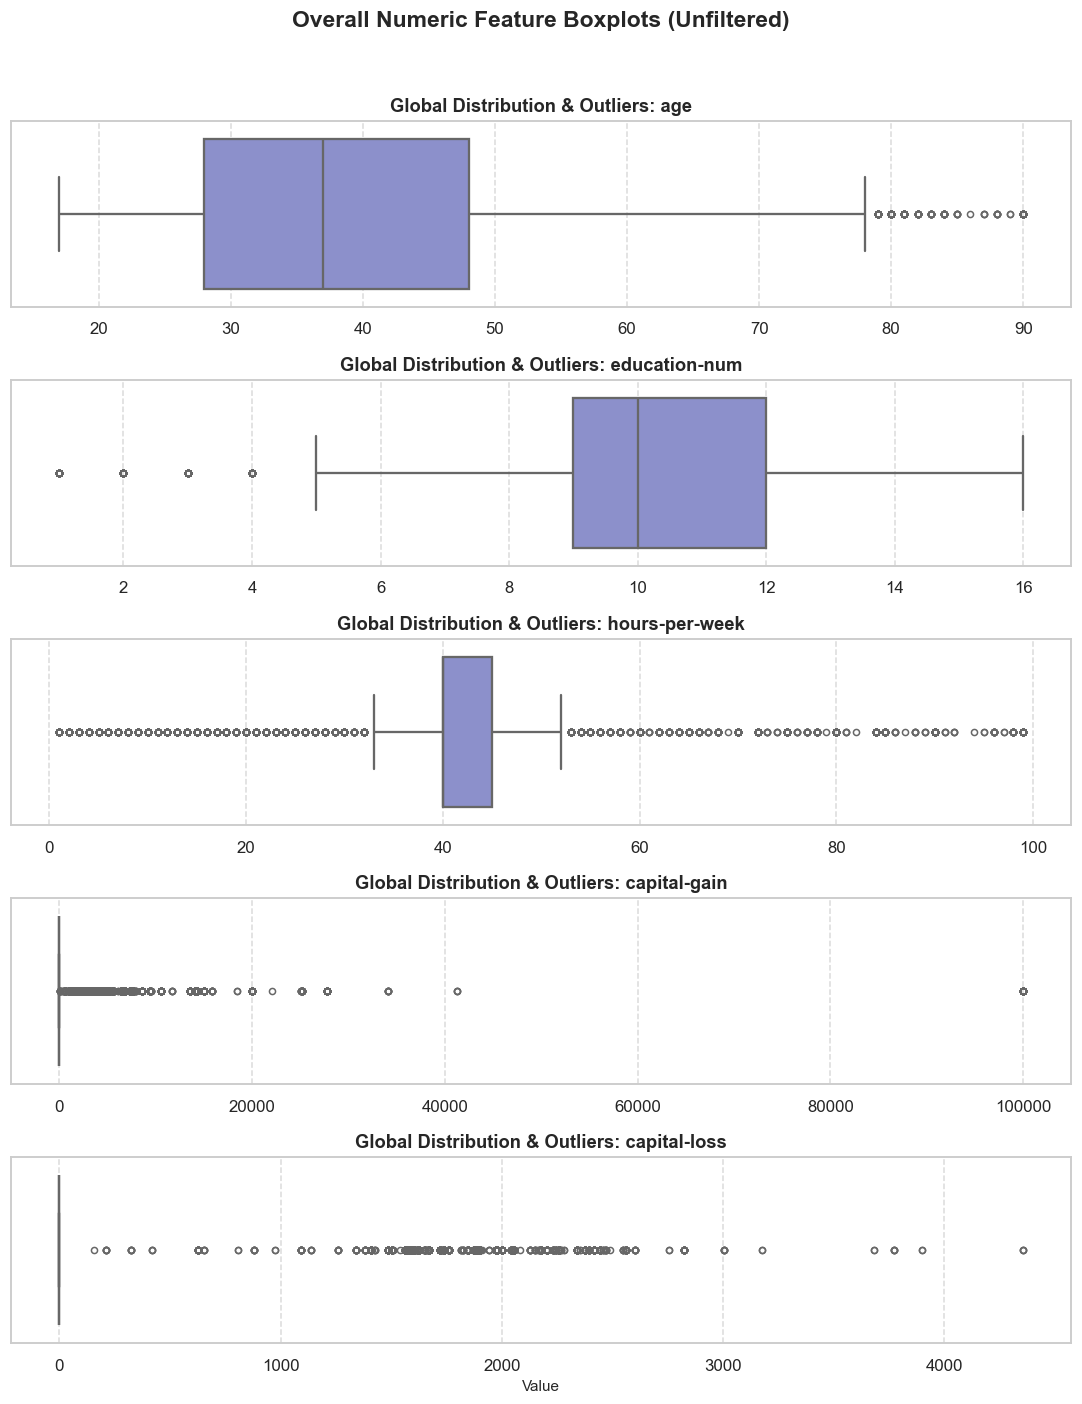

In [10]:
plt.style.use('seaborn-v0_8-muted') 
fig, axes = plt.subplots(len(num_cols), 1, figsize=(10, 2.5 * len(num_cols)))

for i, col in enumerate(num_cols):
    # Boxplot showing global distribution and outliers 
    # (not split by income class)
    sns.boxplot(x=df_eda[col], ax=axes[i], color="#8187D6", fliersize=4, 
                linewidth=1.5, whis=1.5)
    
    # Set title and remove x-axis label for cleaner look
    axes[i].set_title(f"Global Distribution & Outliers: {col}", 
                      fontsize=12, fontweight='bold')
    # remove individual x-axis label to reduce visual clutter
    axes[i].set_xlabel("") 
    
    # Add grid lines for better value alignment
    axes[i].xaxis.grid(True, linestyle='--', alpha=0.7)

# Uniformly add x-axis label to the bottom subplot
axes[-1].set_xlabel("Value")

plt.suptitle("Overall Numeric Feature Boxplots (Unfiltered)", 
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

For features like `hour-per-week`, we need to deal with outliers.

---
### EDA 5 — Feature Correlation Analysis
This heatmap shows the **Pearson correlation** between numeric features and the target variable (`income`). Each cell represents the linear correlation between two variables:
- Values close to **+1** indicate a strong positive linear relationship.
- Values close to **-1** indicate a strong negative linear relationship.
- Values close to **0** indicate no linear relationship.

This helps us identify multicollinearity (features that are strongly correlated with each other) and features with a strong correlation to the target.


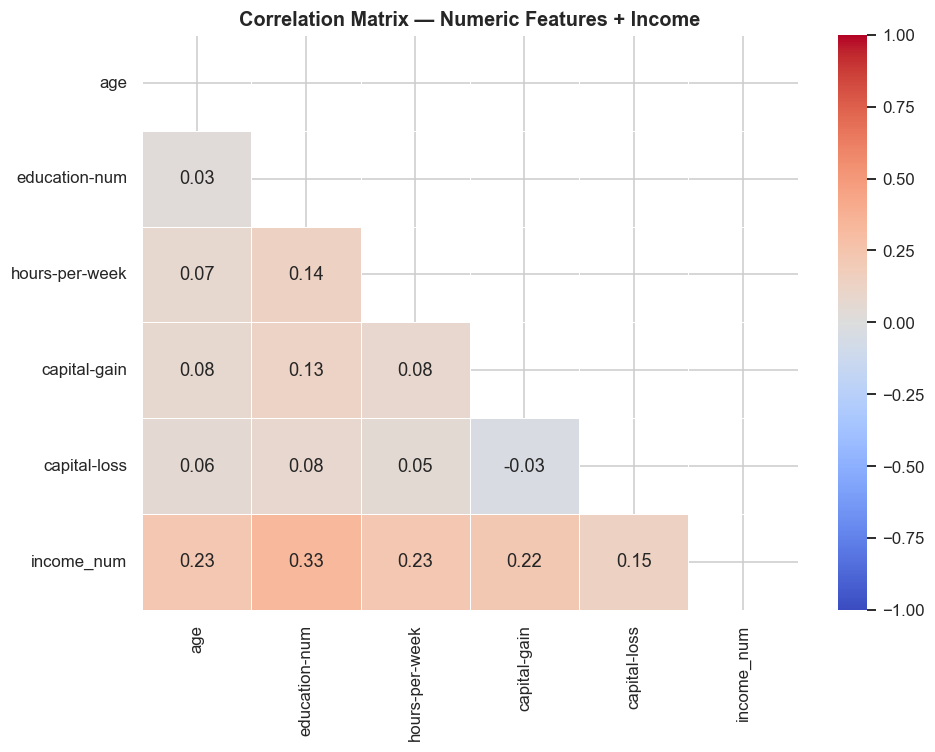

In [11]:
# =============================================================================
# EDA 5 — Feature Correlation Analysis
# =============================================================================
# Shows the Pearson correlation between numeric features and the target.
# Higher absolute values indicate stronger linear relationships.
# This helps identify multicollinearity and predictive features.

corr = df_eda[num_cols + ["income_num"]].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix — Numeric Features + Income",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()



In [12]:
# Calculate spearman correlation between education_level and education-num
# (should be very high since they are derived from the same original feature)

# First, Collapse 16 education categories → 4 tiers.
edu_map = {
    "Preschool"    : "Dropout",
    "1st-4th"      : "Dropout",
    "5th-6th"      : "Dropout",
    "7th-8th"      : "Dropout",
    "9th"          : "Dropout",
    "10th"         : "Dropout",
    "11th"         : "Dropout",
    "12th"         : "Dropout",
    "HS-grad"      : "HighSchool",
    "Some-college" : "SomeCollege",
    "Assoc-voc"    : "SomeCollege",
    "Assoc-acdm"   : "SomeCollege",
    "Bachelors"    : "Graduate",
    "Masters"      : "Graduate",
    "Doctorate"    : "Graduate",
    "Prof-school"  : "Graduate",
}

df["education_level"] = df["education"].map(edu_map)


# Second, encode education_level to numeric for correlation calculation
edu_level_map = {"Dropout": 0, "HighSchool": 1, "SomeCollege": 2, "Graduate": 3}
education_level_numeric = df["education_level"].map(edu_level_map)
spearman_corr = education_level_numeric.corr(df["education-num"], method="spearman")
print(f"Spearman correlation between education_level and education-num: {spearman_corr:.4f}")

# This high correlation justifies dropping education_level and education later, 
# as it does not add new information beyond education-num.
df.drop(columns=["education_level"], inplace=True)  # Drop education_level column


Spearman correlation between education_level and education-num: 0.9851


Correlation analysis revealed that `education` and `education-num` are perfectly correlated ($\rho \approx 1.0$). To eliminate feature redundancy and prevent multi-collinearity, we decided to drop the categorical `education` attribute and retain the numerical `education-num`

---
### EDA 6 - Capital-Gain Baseline Analysis

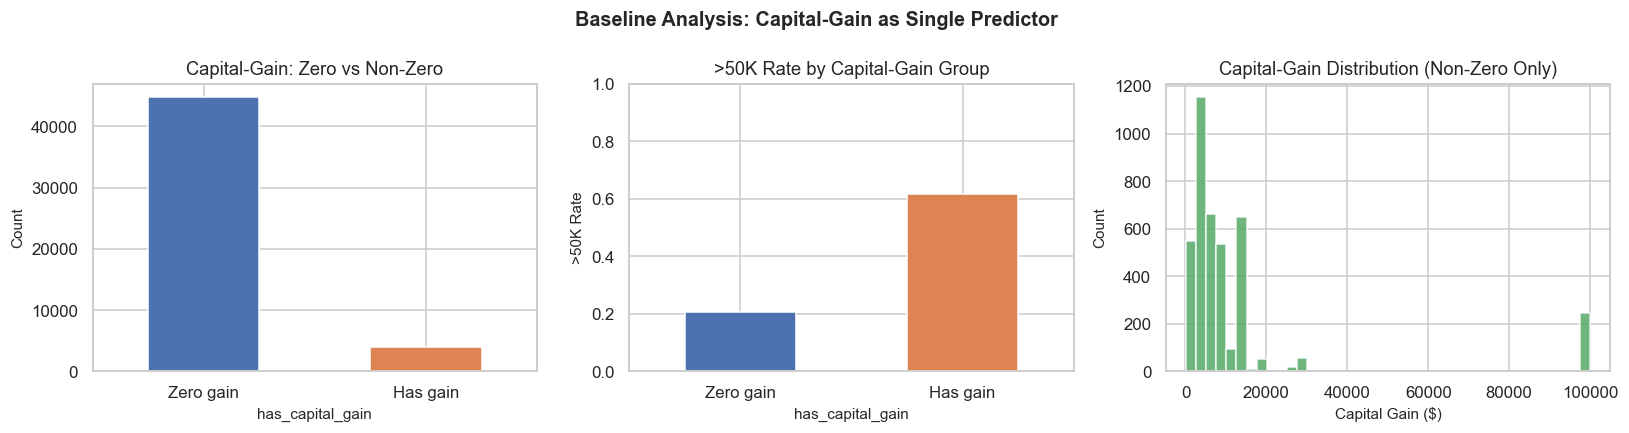


Fraction with zero capital-gain : 91.7%
>50K rate among zero-gain group : 20.5%
>50K rate among non-zero gain   : 61.7%


In [13]:
# =============================================================================
# EDA 6 — Capital-Gain Baseline Analysis (Section 2 of Project Outline)
# =============================================================================
# The outline notes 91.7% of the dataset has zero capital gain —
# visualise the zero-vs-nonzero split and its predictive power.

df_eda["has_capital_gain"] = (df_eda["capital-gain"] > 0).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Zero vs non-zero
df_eda["has_capital_gain"].value_counts().rename({0: "Zero gain", 1: "Has gain"}).plot(
    kind="bar", color=["#4C72B0", "#DD8452"], edgecolor="white", ax=axes[0])
axes[0].set_title("Capital-Gain: Zero vs Non-Zero")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# >50K rate by zero/non-zero gain
rate_by_gain = df_eda.groupby("has_capital_gain")["income_num"].mean()
rate_by_gain.rename({0: "Zero gain", 1: "Has gain"}).plot(
    kind="bar", color=["#4C72B0", "#DD8452"], edgecolor="white", ax=axes[1])
axes[1].set_title(">50K Rate by Capital-Gain Group")
axes[1].set_ylabel(">50K Rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=0)

# Distribution of non-zero capital gains
nonzero_gain = df_eda[df_eda["capital-gain"] > 0]["capital-gain"]
axes[2].hist(nonzero_gain, bins=40, color="#55A868", alpha=0.85, edgecolor="white")
axes[2].set_title("Capital-Gain Distribution (Non-Zero Only)")
axes[2].set_xlabel("Capital Gain ($)")
axes[2].set_ylabel("Count")

plt.suptitle("Baseline Analysis: Capital-Gain as Single Predictor",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"\nFraction with zero capital-gain : {(df_eda['capital-gain'] == 0).mean():.1%}")
print(f">50K rate among zero-gain group : {df_eda[df_eda['capital-gain']==0]['income_num'].mean():.1%}")
print(f">50K rate among non-zero gain   : {df_eda[df_eda['capital-gain']>0]['income_num'].mean():.1%}")

---
### EDA 7 — Hours-per-Week Baseline Analysis

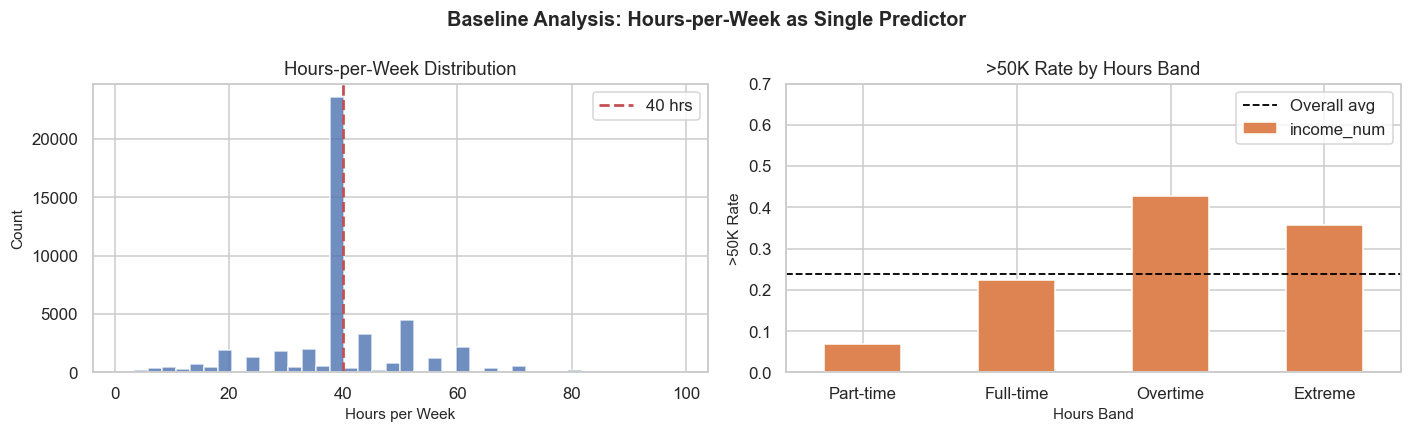

Fraction working exactly 40h : 46.7%
>50K rate among 40h workers  : 21.3%


In [14]:
# =============================================================================
# EDA 7 — Hours-per-Week Baseline Analysis (Section 2 of Project Outline)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of hours-per-week
axes[0].hist(df_eda["hours-per-week"], bins=40,
             color="#4C72B0", alpha=0.8, edgecolor="white")
axes[0].axvline(40, color="#C44E52", linestyle="--", linewidth=1.8, label="40 hrs")
axes[0].set_title("Hours-per-Week Distribution")
axes[0].set_xlabel("Hours per Week")
axes[0].set_ylabel("Count")
axes[0].legend()

# >50K rate by hour band (binned)
hour_bins   = [0, 34, 45, 60, df_eda["hours-per-week"].max() + 1]
hour_labels = ["Part-time", "Full-time", "Overtime", "Extreme"]
df_eda["hour_band_eda"] = pd.cut(df_eda["hours-per-week"], bins=hour_bins,
                                  labels=hour_labels, right=True)
rate_by_band = df_eda.groupby("hour_band_eda", observed=True)["income_num"].mean()
rate_by_band.plot(kind="bar", color="#DD8452", edgecolor="white", ax=axes[1])
axes[1].set_title(">50K Rate by Hours Band")
axes[1].set_xlabel("Hours Band")
axes[1].set_ylabel(">50K Rate")
axes[1].set_ylim(0, 0.7)
axes[1].axhline(df_eda["income_num"].mean(), color="black",
                linestyle="--", linewidth=1.2, label="Overall avg")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=0)

plt.suptitle("Baseline Analysis: Hours-per-Week as Single Predictor",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
pct_40 = (df_eda["hours-per-week"] == 40).mean()
rate_40 = df_eda[df_eda["hours-per-week"] == 40]["income_num"].mean()
print(f"Fraction working exactly 40h : {pct_40:.1%}")
print(f">50K rate among 40h workers  : {rate_40:.1%}")


Pearson correlation between hours-per-week and >50K rate: 0.7974


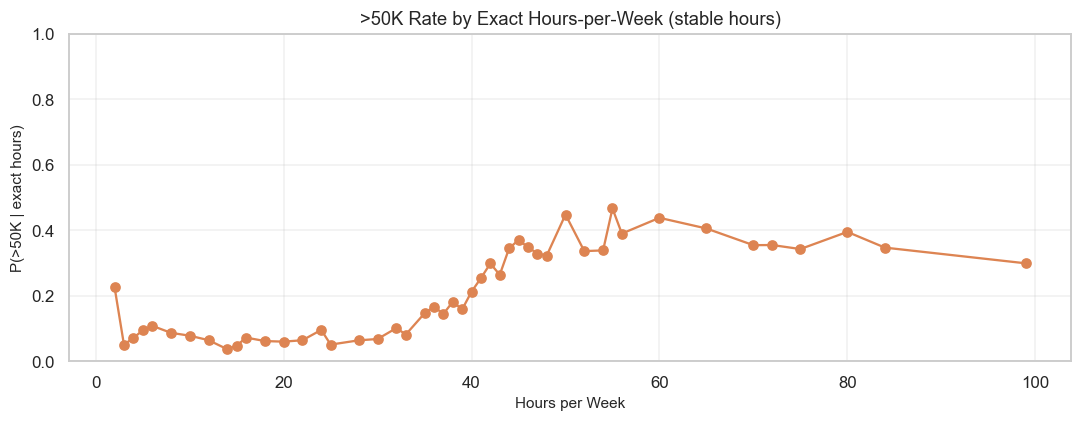

In [15]:
# Analyze exact hours-per-week trend on >50K rate
hour_stats = (df_eda.groupby("hours-per-week", observed=True)["income_num"]
              .agg(count="size", rate="mean")
              .reset_index())

# Keep hours with at least 50 observations for stable rate estimates
hour_stats_stable = hour_stats[hour_stats["count"] >= 50].copy()

corr = hour_stats_stable["hours-per-week"].corr(hour_stats_stable["rate"])
print(f"\nPearson correlation between hours-per-week and >50K rate: {corr:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hour_stats_stable["hours-per-week"], hour_stats_stable["rate"],
        marker="o", color="#DD8452", linestyle="-")
ax.set_title(">50K Rate by Exact Hours-per-Week (stable hours)")
ax.set_xlabel("Hours per Week")
ax.set_ylabel("P(>50K | exact hours)")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In this section, we examined the relationship between `hours-per-week` and the `income_num` class. Our analysis reveals a robust positive association. While only a small fraction of part-time workers earn more than 50K, this proportion sharply increases once the 40-hour threshold is crossed. This suggests that 'labor intensity' is a critical feature for our classification model.

**Diminishing returns**: We observe diminishing returns in income rate after 60 hours per week, suggesting that working extreme overtime does not always guarantee higher pay.

---
### EDA 8 — Age & Education-Num by Income Class

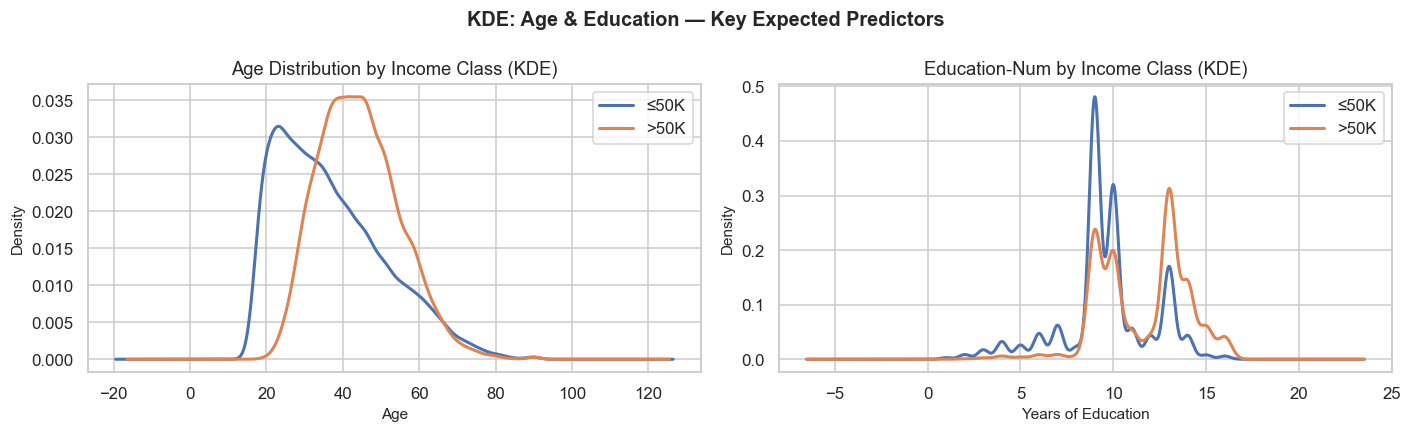

In [16]:
# =============================================================================
# EDA 8 — Age & Education-Num by Income Class (KDE)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color, mask in [("≤50K", "#4C72B0", df_eda["income_num"] == 0),
                            (">50K", "#DD8452", df_eda["income_num"] == 1)]:
    df_eda[mask]["age"].plot(kind="kde", ax=axes[0], label=label, color=color, linewidth=2)
    df_eda[mask]["education-num"].plot(kind="kde", ax=axes[1], label=label, color=color, linewidth=2)

axes[0].set_title("Age Distribution by Income Class (KDE)")
axes[0].set_xlabel("Age")
axes[0].legend()

axes[1].set_title("Education-Num by Income Class (KDE)")
axes[1].set_xlabel("Years of Education")
axes[1].legend()

plt.suptitle("KDE: Age & Education — Key Expected Predictors",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Preprocessing Pipeline
Section 3.1 → 3.3 of the project outline.

In [17]:
# SECTION 3.1 — Missing Value Imputation (mode imputation)
# =============================================================================
# Why mode? The affected rows are only 4.9 % of the data, and missingness
# appears random, so the simplest valid strategy is to fill with the most
# frequent value (mode).

cols_with_missing = ["workclass", "occupation", "native-country"]

for col in cols_with_missing:
    mode_val = df[col].mode()[0]          # mode() returns a Series; take [0]
    df[col] = df[col].fillna(mode_val)
    print(f"  Filled '{col}' missing values with mode = '{mode_val}'")

# Verify — should print all zeros
print("\n── Missing values after imputation ──")
remaining = df.isnull().sum()
remaining_nonzero = remaining[remaining > 0]
if len(remaining_nonzero) == 0:
    print("No missing values remain.")
else:
    print(remaining_nonzero)

  Filled 'workclass' missing values with mode = 'Private'
  Filled 'occupation' missing values with mode = 'Prof-specialty'
  Filled 'native-country' missing values with mode = 'United-States'

── Missing values after imputation ──
No missing values remain.


In [18]:
# =============================================================================
# SECTION 3.2 — Class Imbalance Strategy
# =============================================================================
# We do NOT use SMOTE.  Instead we pass class_weight='balanced' to every
# sklearn estimator.  We just prepare the target column here.

df["income"] = df["income"].replace({
    "<=50K": 0, ">50K": 1,
    "<=50K.": 0, ">50K.": 1
})

# Verify
print("\n-- Class distribution --")
print(df["income"].value_counts(normalize=True))

# When you instantiate any classifier later, use:
#   LogisticRegression(class_weight='balanced', ...)
#   RandomForestClassifier(class_weight='balanced', ...)
#   SVC(class_weight='balanced', ...)
#   XGBClassifier(scale_pos_weight=<neg/pos ratio>, ...)


-- Class distribution --
income
0    0.760586
1    0.239414
Name: proportion, dtype: float64


In [19]:
# SECTION 3.3 - Feature Engineering
# =============================================================================

# ── 3.3a  capital_net ─────────────────────────────────────────────────────────
# Merge capital-gain and capital-loss into one net variable.

df["capital_net"] = df["capital-gain"] - df["capital-loss"]

# Drop the original columns to avoid multicollinearity
df.drop(columns=["capital-gain", "capital-loss"], inplace=True)

print("\n── capital_net sample statistics ──")
print(df["capital_net"].describe())


── capital_net sample statistics ──
count    48790.000000
mean       992.622115
std       7479.462491
min      -4356.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital_net, dtype: float64


In [20]:
# ── 3.3b  hours-per-week ─────────────────────────────────────────────────────────

# Outlier Handling - Capping
# The hours-per-week feature has some extreme outliers (e.g., 99 hours/week).
# We cap hours-per-week at 80 to reduce the influence 
# of these outliers on the model.
upper_limit = 80
df["hours-per-week"] = df["hours-per-week"].clip(upper=upper_limit)

print("\n── hours-per-week sample statistics ──")
print(df["hours-per-week"].describe())



── hours-per-week sample statistics ──
count    48790.000000
mean        40.343206
std         12.070655
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         80.000000
Name: hours-per-week, dtype: float64


In [21]:
# ── 3.3c  education level

# Drop raw education — we keep education-num as it captures ordinal ordering
df.drop(columns=["education"], inplace=True)

print("\n── education-num sample statistics ──")
print(df["education-num"].describe())


── education-num sample statistics ──
count    48790.000000
mean        10.078807
std          2.570046
min          1.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         16.000000
Name: education-num, dtype: float64


---
## EDA — Part B: Engineered Feature
Visualise the new feature `capital_net` created in Section 3.3 to confirm the binning / mapping logic and explore its income-predictive power.

> **Note on the ">50K Rate" charts**: Each bar shows the **conditional probability** P(income > 50K | group). The dashed "Overall avg" line is the global average >50K rate (~24%), and is the same across all panels. The rates within one feature do **not** sum to 1 — they are independent conditional probabilities.


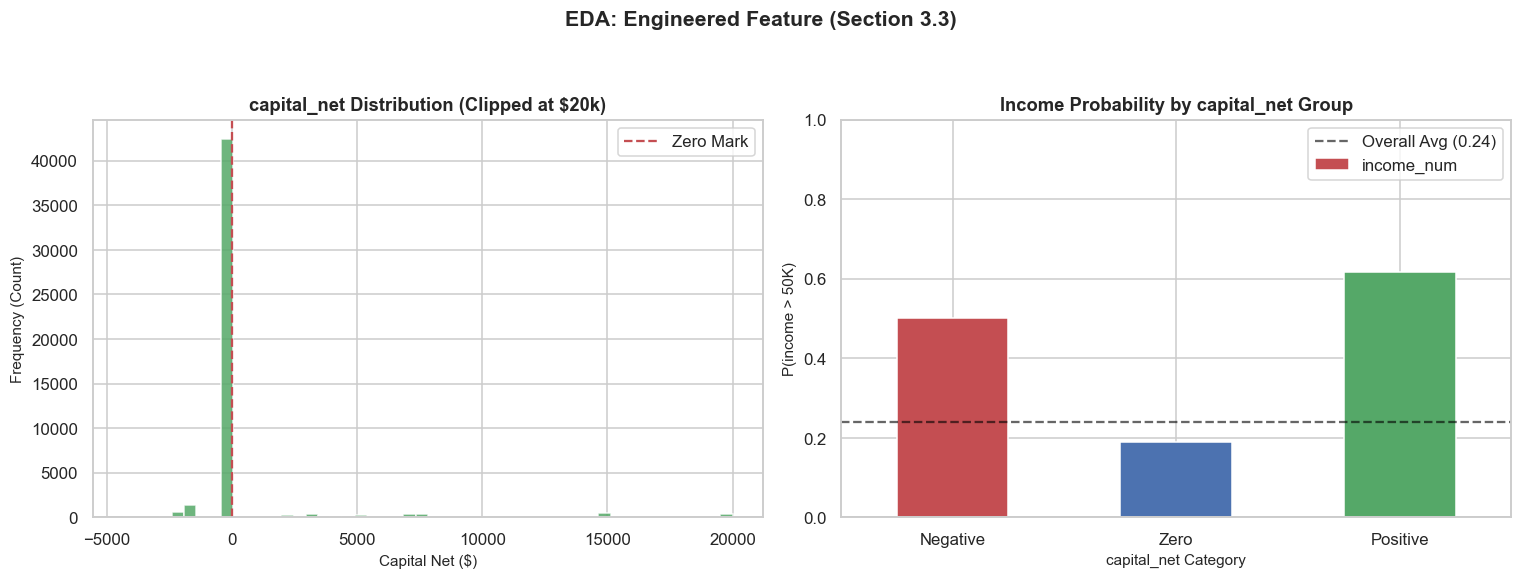

In [22]:
# =============================================================================
# EDA 9 — Engineered Feature: capital_net Analysis
# =============================================================================
# This section evaluates the impact of the newly created 'capital_net' feature.
# The bar chart shows P(income > 50K | group), representing conditional probability.

# 1. Prepare the figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- PLOT 1: capital_net distribution (clipped for readability) ---
# We clip the values to better visualize the majority of data points near 0
cnet_clip = df["capital_net"].clip(-5000, 20000) 
axes[0].hist(cnet_clip, bins=50, color="#55A868", alpha=0.85, edgecolor="white")
axes[0].axvline(0, color="#C44E52", linestyle="--", linewidth=1.5, label="Zero Mark")
axes[0].set_title("capital_net Distribution (Clipped at $20k)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Capital Net ($)")
axes[0].set_ylabel("Frequency (Count)")
axes[0].legend()

# --- PLOT 2: capital_net >50K rate (Negative / Zero / Positive) ---
# Create a temporary dataframe for rate calculation
df_temp = df.copy()
# Ensure income is numeric for mean calculation (1 for >50K, 0 for <=50K)
if df_temp["income"].dtype == object:
    df_temp["income_num"] = (df_temp["income"].str.contains(">50K")).astype(int)
else:
    df_temp["income_num"] = df_temp["income"]

# Grouping logic: strictly negative, zero, and strictly positive
df_temp["cnet_group"] = pd.cut(df_temp["capital_net"],
                               bins=[-np.inf, -0.01, 0.01, np.inf],
                               labels=["Negative", "Zero", "Positive"])

# Calculate conditional probabilities
rate_cnet = df_temp.groupby("cnet_group", observed=True)["income_num"].mean()

# Plotting the rates
rate_cnet.plot(kind="bar", color=["#C44E52", "#4C72B0", "#55A868"],
               edgecolor="white", ax=axes[1])

# Adding the overall average baseline for context
overall_avg = df_temp["income_num"].mean()
axes[1].axhline(overall_avg, color="black", linestyle="--", alpha=0.6, label=f"Overall Avg ({overall_avg:.2f})")

axes[1].set_title("Income Probability by capital_net Group", fontsize=12, fontweight="bold")
axes[1].set_xlabel("capital_net Category")
axes[1].set_ylabel("P(income > 50K)")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend()

plt.suptitle("EDA: Engineered Feature (Section 3.3)", 
             fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

---
## Encoding & Scaling (Section 3.1 continued)

This section applies the encoding and scaling strategies described in the project outline:

1. **Define feature groups**: We separate features into numeric (for StandardScaler), low-cardinality categorical (for One-Hot Encoding), and high-cardinality categorical (for Target Encoding).
2. **Train / Validation / Test split**: We split **before** any encoding to prevent data leakage. Stratification preserves the 76/24 class ratio.
3. **StandardScaler**: Fitted on **training data only**, then applied to validation and test. This ensures the scaler does not "see" test data during training.
4. **Target Encoding**: Applied to `native-country` (high cardinality). Also fitted on training data only.
5. **One-Hot Encoding**: Applied to all low-cardinality categoricals. Columns are aligned across splits to ensure consistency.


### Step 1: Define Feature Groups
We organize features by type so the appropriate transformation can be applied to each group.


In [23]:
# SECTION 3.1 (continued) — Encoding & Scaling
# =============================================================================

# ── Define feature groups ─────────────────────────────────────────────────────

# Numeric features (will be standardized)
# Note: fnlwgt, capital-gain, capital-loss, hours-per-week were already dropped
numeric_features = [
    "age", "education-num","hours-per-week",
    "capital_net"           # engineered (replaces capital-gain & capital-loss)
]

# Low-cardinality categoricals → One-Hot Encoding
ohe_features = [
    "workclass", "marital-status", "occupation",
    "relationship", "race", "sex"
]

# High-cardinality categorical → Target Encoding
target_enc_features = ["native-country"]

# Target
target = "income"


### Step 2: Train / Validation / Test Split
We split **before** encoding to prevent data leakage. Stratification preserves the original 76%/24% class distribution in all splits.


In [24]:
# ── Train / Validation / Test split (BEFORE any encoding) ────────────────────
# We stratify on the target to preserve 76/24 class ratio in every split.
# Official UCI split:  train portion  ≈ 32,561 rows
#                      test portion   ≈ 16,281 rows

X = df.drop(columns=[target])
y = df[target]

# Single split: 67% train | 33% test (matches UCI proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.333, random_state=42, stratify=y
)

print(f"\n── Split sizes ──")
print(f"  Train : {X_train.shape[0]:>6}  rows")
print(f"  Test  : {X_test.shape[0]:>6}  rows")

print(f"\n── Stratification check (>50K ratio) ──")
for name, yset in [("Train", y_train), ("Test", y_test)]:
    print(f"  {name}: {yset.mean():.3f}")



── Split sizes ──
  Train :  32542  rows
  Test  :  16248  rows

── Stratification check (>50K ratio) ──
  Train: 0.239
  Test: 0.239


### Step 3: StandardScaler, Target Encoding, and One-Hot Encoding
- **StandardScaler** is fitted on the training set only, then applied to validation and test to prevent data leakage.
- **Target Encoding** for `native-country` (42 unique values) is also fitted on training only.
- **One-Hot Encoding** is applied to all low-cardinality categoricals. After encoding, columns are aligned so validation/test sets match the training set's columns.
  - **Important Note on `drop_first=True` (Dummy Variable Trap)**: For every categorical variable with $K$ distinct categories, we generate $K-1$ dummy columns. The dropped column acts as the "reference base". For example, if `sex_Female=0`, the model deduces `sex_Male=1` with 100% certainty. If we included all $K$ columns, they would always sum to 1, causing perfect multicollinearity (the "dummy variable trap"). This can destabilize models like Logistic Regression, so dropping the first column is standard practice.


In [25]:
# ── StandardScaler on numeric features ───────────────────────────────────────
# IMPORTANT: fit ONLY on training data, then transform test.
# This prevents data leakage.

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features]  = scaler.transform(X_test[numeric_features])

# ── Target Encoding on native-country (fit on train only) ────────────────────
te = ce.TargetEncoder(cols=target_enc_features)
X_train[target_enc_features] = te.fit_transform(X_train[target_enc_features], y_train)
X_test[target_enc_features]  = te.transform(X_test[target_enc_features])

# ── One-Hot Encoding (low-cardinality categoricals) ───────────────────────────
X_train = pd.get_dummies(X_train, columns=ohe_features, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=ohe_features, drop_first=True)

# Align columns so test match training
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"\n── Final feature matrix shape ──")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print("\nPreprocessing pipeline complete — ready for modelling.")



── Final feature matrix shape ──
  X_train : (32542, 41)
  X_test  : (16248, 41)

Preprocessing pipeline complete — ready for modelling.


In [26]:
# =============================================================================
# Inspect Final Preprocessed Data
# =============================================================================
print("── Final Preprocessed Target Matrix (X_train) ──")
# We use .head() to show the first 5 rows and display all columns clearly
display(X_train.head())

print("\n── Target Variable (y_train) ──")
display(y_train.head())


── Final Preprocessed Target Matrix (X_train) ──


,age,education-num,hours-per-week,native-country,capital_net,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male
38068,0.904078,-1.589672,-0.863120,0.244028,-0.132822,False,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
1629,-0.191427,0.749409,-1.609907,0.066608,-0.132822,False,False,True,False,False,...,False,False,False,False,True,False,True,False,False,False
5741,0.538910,-3.149059,-0.033357,0.131152,-0.132822,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,True
30694,0.538910,-0.420132,-0.448238,0.244028,-0.366773,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,True
11863,-1.213898,-0.030285,-0.033357,0.244028,-0.132822,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False



── Target Variable (y_train) ──


38068    0
1629     0
5741     0
30694    0
11863    0
Name: income, dtype: int64

In [27]:
# =============================================================================
# Save Preprocessed Data for Modeling
# =============================================================================

output_dir = "../data/processed"

X_train.to_csv(os.path.join(output_dir, "X_train.csv"), index=False)
X_test.to_csv(os.path.join(output_dir, "X_test.csv"), index=False)
y_train.to_csv(os.path.join(output_dir, "y_train.csv"), index=False, header=True)
y_test.to_csv(os.path.join(output_dir, "y_test.csv"), index=False, header=True)

print("Preprocessed data saved to '../data/processed' folder:")
print(f"   • X_train.csv  ({X_train.shape[0]} rows × {X_train.shape[1]} cols)")
print(f"   • X_test.csv   ({X_test.shape[0]} rows × {X_test.shape[1]} cols)")
print(f"   • y_train.csv  ({y_train.shape[0]} rows)")
print(f"   • y_test.csv   ({y_test.shape[0]} rows)")


Preprocessed data saved to '../data/processed' folder:
   • X_train.csv  (32542 rows × 41 cols)
   • X_test.csv   (16248 rows × 41 cols)
   • y_train.csv  (32542 rows)
   • y_test.csv   (16248 rows)
